# Chapter 1 · The streaming world — a release-and-decay DGP

**Where the whole lab starts.** Before we can measure whether *ad spend causes streams* (Chapter 3
onward), we need data we fully understand. So we don't start from a messy export — we **author the
world**: a data-generating process (DGP) whose every ingredient we set by hand. The pay-off is the
throughline of this entire project — **because we planted the truth, we can later *score* any estimator
against it.** A method that can't recover a known effect on data we built has no business being trusted on
real data we didn't.

This first chapter has no causal question yet. Its job is to build a panel that *looks like* real
streaming data and to **earn your trust in the simulator** by checking that what we put in comes back out:
catalog growth, release spikes that decay, Friday/weekend seasonality, the occasional viral hit, and the
brutal concentration where a handful of tracks capture most of the streams.

**Roadmap.** §1 generate the world · §2 a glance at the panel · §3 time series (catalog + track level) ·
§4 recover the decay half-life (the first "did we get back what we built?" check) · §5 seasonality ·
§6 the heavy-tailed distribution · §7 concentration (Gini/Lorenz) · §8 a per-track table · §9 takeaways.

The DGP itself lives in the shared `mml` module — `simulate_catalog` returns a release table (`tracks`)
and a long daily-streams panel (`panel`). This chapter just imports it and interrogates it. *(Watch for
two things that matter far downstream: the **heavy tail** — a few hits dominate — and the fact that each
release has only a short, noisy life. Both are exactly why naïve per-release measurement fails and why
Chapter 4 has to **pool** across the roster.)*

---

## The model

We observe **artists**, each releasing one or more **tracks**, and we record the
**daily streams** of every track from its release date to the end of the window.

For track $i$ on a calendar day with weekday $w$, let $a$ be days since release.
Expected streams are

$$
\mu_{i,a} \;=\; \underbrace{P_{\text{artist}(i)}\cdot Q_i}_{\text{peak level }\beta_i}
\;\times\; \underbrace{e^{-\lambda_i a}}_{\text{decay}}
\;\times\; \underbrace{s_w}_{\text{day-of-week}}
\;\times\; \underbrace{\bigl(1+v_{i,a}\bigr)}_{\text{viral bump}}
$$

and observed streams are an **over-dispersed count**

$$
y_{i,a}\ \sim\ \text{NegBinomial}(\text{mean}=\mu_{i,a},\ r),\qquad
\operatorname{Var}(y)=\mu+\mu^2/r .
$$

**Ingredients (all heterogeneous and log-normal where it matters):**

| Component | Symbol | Meaning |
|---|---|---|
| Artist popularity | $P$ | log-normal; sets each artist's scale |
| Track quality | $Q$ | log-normal; some tracks are hits, most are not |
| Peak level | $\beta_i=P\cdot Q$ | expected day-0 streams |
| Decay rate | $\lambda_i=\ln 2/h_i$ | half-life $h_i$ log-normal; better tracks decay a bit slower |
| Day-of-week | $s_w$ | weekly seasonality, **Friday / weekend lift** |
| Viral bump | $v_{i,a}$ | rare transient shocks (playlist / TikTok), exponential fade |
| Over-dispersion | $r$ | NegBinomial; real counts are spikier than Poisson |

The combination of log-normal $P\cdot Q$ **and** viral shocks is what produces the
realistic **concentration** (a few hits dominate), which we measure with a Gini
coefficient and a Lorenz curve below.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import sys, pathlib; sys.path.insert(0, str(pathlib.Path.cwd().parent))
from mml import simulate_catalog, gini

import matplotlib.dates as mdates

plt.rcParams.update({
    "figure.figsize": (11, 4.5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

## 1 · Generate the world

`simulate_catalog` builds the catalog: each artist gets a latent popularity and a
random number of tracks; each track gets a quality, a release date, and a decay
half-life; then every track is walked forward from its release date applying
decay × seasonality × viral bumps to get the mean $\mu$, and an over-dispersed count is
drawn. Everything is driven by the seed — change it and re-run for a new world.

In [2]:
tracks, panel = simulate_catalog(seed=0)

dates = pd.to_datetime(panel.date).sort_values().unique()
dates = pd.DatetimeIndex(dates)
n_days = len(dates)
print(f"Observation window: {dates[0].date()} -> {dates[-1].date()}  ({n_days} days)")
print(f"{tracks.artist_id.nunique()} artists, {len(tracks)} tracks")
tracks.head()

Observation window: 2024-01-01 -> 2025-12-31  (731 days)
30 artists, 133 tracks


,track_id,artist_id,peak,quality,half_life,release_date
0,T000,A00,3591.594120,1.583629,29.186238,2024-09-26
1,T001,A00,1300.986839,0.573639,21.838342,2024-08-10
2,T002,A00,4416.098223,1.947174,50.209545,2025-04-27
3,T003,A01,1342.062923,0.765800,43.036945,2025-02-13
4,T004,A01,9274.436818,5.292123,65.987327,2024-09-27


The long panel — one row per track-day, with the latent mean `mu` kept alongside the
observed `streams` count.

In [3]:
panel = panel.sort_values(["date", "track_id"]).reset_index(drop=True)
print(f"Panel: {len(panel):,} track-day observations")
panel.head()

Panel: 49,033 track-day observations


,date,track_id,artist_id,days_since_release,streams,mu
0,2024-01-01,T067,A16,0,764,550.915227
1,2024-01-02,T067,A16,1,609,511.836688
2,2024-01-03,T067,A16,2,379,496.202973
3,2024-01-04,T067,A16,3,594,495.704715
4,2024-01-05,T067,A16,4,636,555.126999


## 2 · The panel at a glance

In [4]:
total_streams = panel.streams.sum()
summary = pd.Series({
    "Artists":              tracks.artist_id.nunique(),
    "Tracks":               tracks.track_id.nunique(),
    "Days observed":        n_days,
    "Track-day rows":       len(panel),
    "Total streams":        int(total_streams),
    "Mean streams / row":   panel.streams.mean(),
    "Median streams / row": panel.streams.median(),
    "Max single-day":       int(panel.streams.max()),
})
print(summary.to_frame("value"))

                             value
Artists               3.000000e+01
Tracks                1.330000e+02
Days observed         7.310000e+02
Track-day rows        4.903300e+04
Total streams         2.380029e+07
Mean streams / row    4.853932e+02
Median streams / row  7.000000e+00
Max single-day        2.709070e+05


## 3 · Time series

### 3.1 Catalog-level: total daily streams

As releases accumulate the catalog grows; weekly seasonality shows up as the
high-frequency ripple.

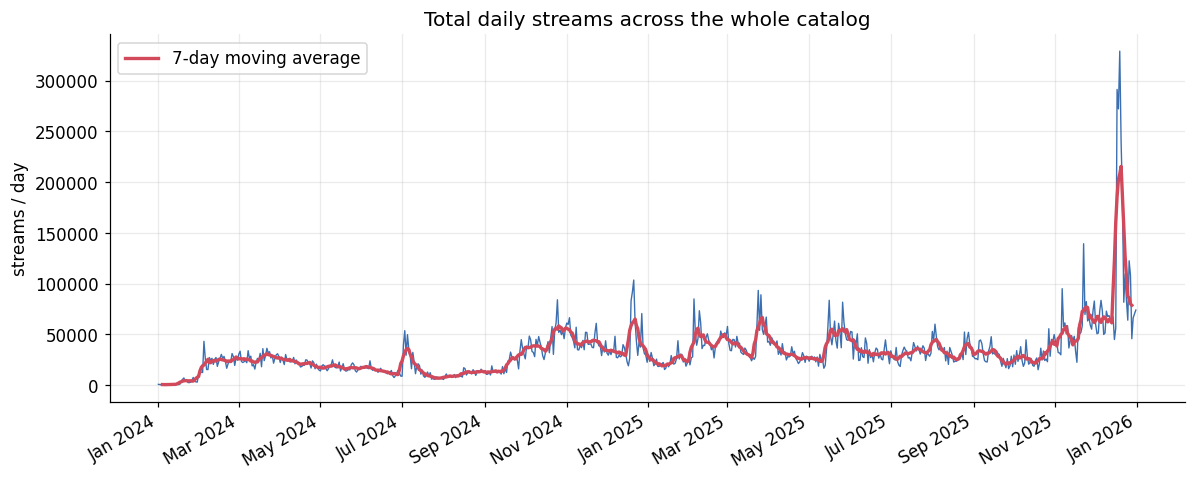

In [5]:
daily_total = panel.groupby("date").streams.sum()

fig, ax = plt.subplots()
ax.plot(daily_total.index, daily_total.values, lw=0.9, color="#3b6fb0")
ax.plot(daily_total.index, daily_total.rolling(7, center=True).mean(),
        lw=2.2, color="#d1495b", label="7-day moving average")
ax.set_title("Total daily streams across the whole catalog")
ax.set_ylabel("streams / day"); ax.legend()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
fig.autofmt_xdate(); plt.tight_layout(); plt.show()

### 3.2 Track-level trajectories

A hit, a typical track, and a flop — note the release spike, the exponential decay, and
any viral bumps. Log scale on the right makes the decay roughly linear.

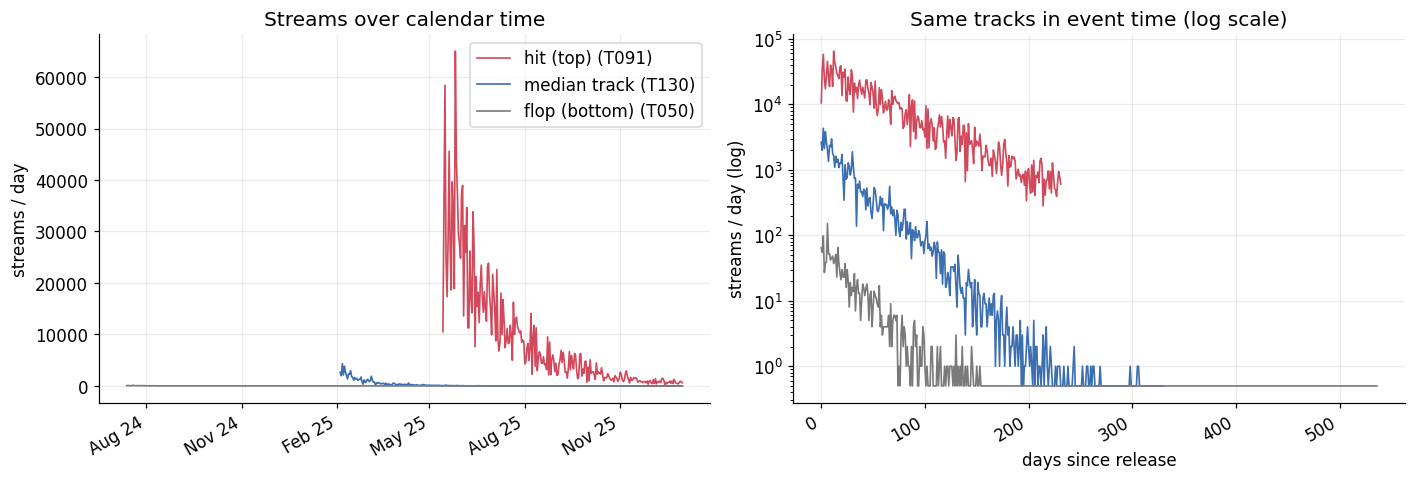

In [6]:
totals = panel.groupby("track_id").streams.sum().sort_values()
picks = {
    "hit (top)":      totals.index[-1],
    "median track":   totals.index[len(totals)//2],
    "flop (bottom)":  totals.index[0],
}
colors = {"hit (top)": "#d1495b", "median track": "#3b6fb0", "flop (bottom)": "#7a7a7a"}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
for label, tid in picks.items():
    d = panel[panel.track_id == tid]
    ax1.plot(d.date, d.streams, lw=1.1, color=colors[label], label=f"{label} ({tid})")
    ax2.plot(d.days_since_release, d.streams.clip(lower=0.5), lw=1.1, color=colors[label])
ax1.set_title("Streams over calendar time"); ax1.set_ylabel("streams / day"); ax1.legend()
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
ax2.set_yscale("log"); ax2.set_title("Same tracks in event time (log scale)")
ax2.set_xlabel("days since release"); ax2.set_ylabel("streams / day (log)")
fig.autofmt_xdate(); plt.tight_layout(); plt.show()

### 3.3 The top 10 releases — when the hits landed

The ten biggest tracks by lifetime streams, each as its own daily time series. Because they drop on
different Fridays you can read the **release calendar** straight off the spikes — and see how fast even a
hit fades. **What to look for:** a few tall, narrow spikes carry the catalog (the concentration of §7,
made visual), and every one of them decays within weeks — there's no such thing as a permanent hit here.

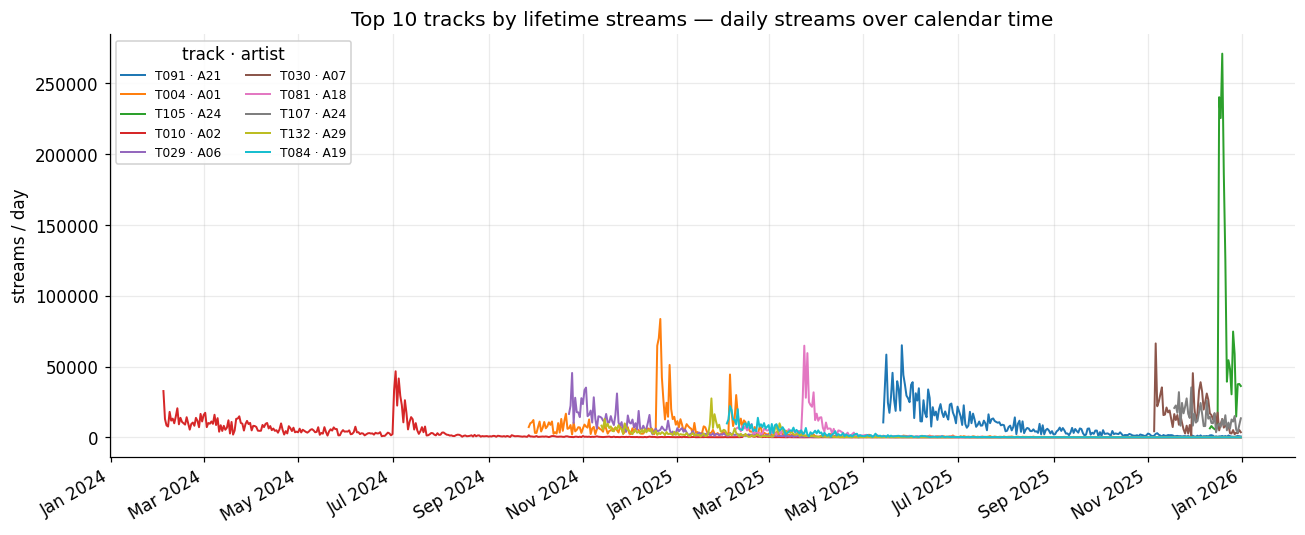

In [7]:
top10 = panel.groupby("track_id").streams.sum().sort_values().index[-10:][::-1]
fig, ax = plt.subplots(figsize=(12, 5))
for tid, col in zip(top10, plt.cm.tab10(np.linspace(0, 1, 10))):
    d = panel[panel.track_id == tid]
    ax.plot(d.date, d.streams, lw=1.3, color=col, label=f"{tid} · {d.artist_id.iloc[0]}")
ax.set_title("Top 10 tracks by lifetime streams — daily streams over calendar time")
ax.set_ylabel("streams / day")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.legend(ncol=2, fontsize=8, framealpha=0.9, title="track · artist")
fig.autofmt_xdate(); plt.tight_layout(); plt.show()

## 4 · Decay structure (event time) — our first recovery check

This is the **template for the whole lab in miniature.** We *planted* a per-track half-life (median ≈ 25
days); can we *recover* it from the simulated streams alone? Aligning every track to its own release day
and averaging washes out the idiosyncratic noise and leaves the common **exponential decay**. On a log
axis an exponential is a straight line, so a simple linear fit to `log(mean streams)` gives the implied
half-life. **What to look for:** the recovered half-life should land near the input (it won't match
exactly — averaging mixes tracks with different half-lives, and the heavy right tail tugs the mean up).
When a known quantity comes back out, the simulator has earned a little trust; that is precisely the move
we'll make for *causal* effects from Chapter 3 on, where the planted quantity is an ad-spend lift.

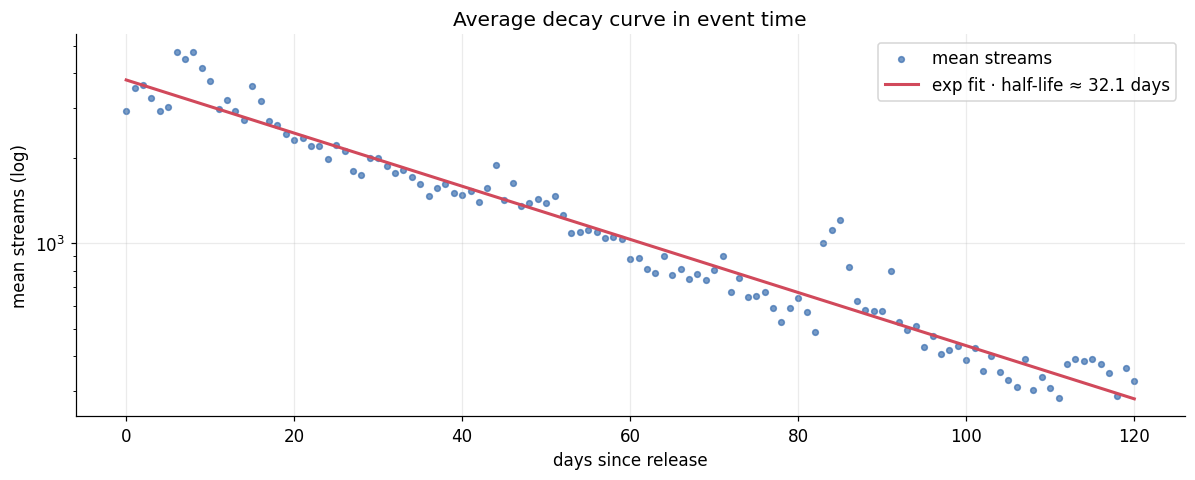

Implied catalog half-life: 32.1 days (median input half-life was 24.5 days)


In [8]:
HORIZON = 120
ev = (panel[panel.days_since_release <= HORIZON]
      .groupby("days_since_release").streams.mean())

a = ev.index.to_numpy()
slope, intercept = np.polyfit(a, np.log(ev.values), 1)
implied_hl = np.log(2) / (-slope)
fit = np.exp(intercept + slope * a)

fig, ax = plt.subplots()
ax.scatter(a, ev.values, s=14, color="#3b6fb0", alpha=0.7, label="mean streams")
ax.plot(a, fit, color="#d1495b", lw=2,
        label=f"exp fit · half-life ≈ {implied_hl:,.1f} days")
ax.set_yscale("log"); ax.set_title("Average decay curve in event time")
ax.set_xlabel("days since release"); ax.set_ylabel("mean streams (log)"); ax.legend()
plt.tight_layout(); plt.show()
print(f"Implied catalog half-life: {implied_hl:,.1f} days "
      f"(median input half-life was {tracks.half_life.median():,.1f} days)")

## 5 · Day-of-week seasonality

Residualised against each track's own mean so the weekly pattern isn't swamped by level
differences. The **Friday / weekend lift** is the signal we injected.

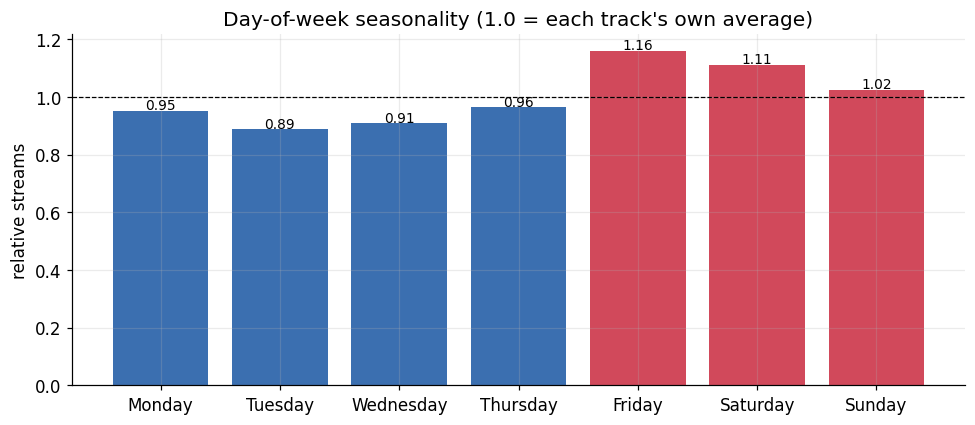

Weekend/Fri vs Mon-Thu lift: 18.3%


In [9]:
tmp = panel.copy()
tmp["weekday"] = pd.Categorical(
    pd.to_datetime(tmp.date).dt.day_name(),
    categories=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"],
    ordered=True)
tmp["rel"] = tmp.streams / tmp.groupby("track_id").streams.transform("mean")
dow = tmp.groupby("weekday", observed=True).rel.mean()

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(dow.index.astype(str), dow.values,
              color=["#3b6fb0"]*4 + ["#d1495b"]*3)
ax.axhline(1.0, color="k", lw=0.8, ls="--")
ax.set_title("Day-of-week seasonality (1.0 = each track's own average)")
ax.set_ylabel("relative streams")
for b, v in zip(bars, dow.values):
    ax.text(b.get_x()+b.get_width()/2, v+0.005, f"{v:.2f}", ha="center", fontsize=9)
plt.tight_layout(); plt.show()
print("Weekend/Fri vs Mon-Thu lift: "
      f"{dow[['Friday','Saturday','Sunday']].mean()/dow[['Monday','Tuesday','Wednesday','Thursday']].mean()-1:.1%}")

## 6 · Distribution of daily streams

Heavy right tail and over-dispersion — most track-days are small, a few are enormous.
Shown on a log-x histogram.

             daily streams
count         49033.000000
mean            485.393225
std            3114.099922
min               0.000000
25%               0.000000
50%               7.000000
75%             153.000000
max          270907.000000
skew             41.422526
kurtosis       2829.840069
% zero days      35.922746


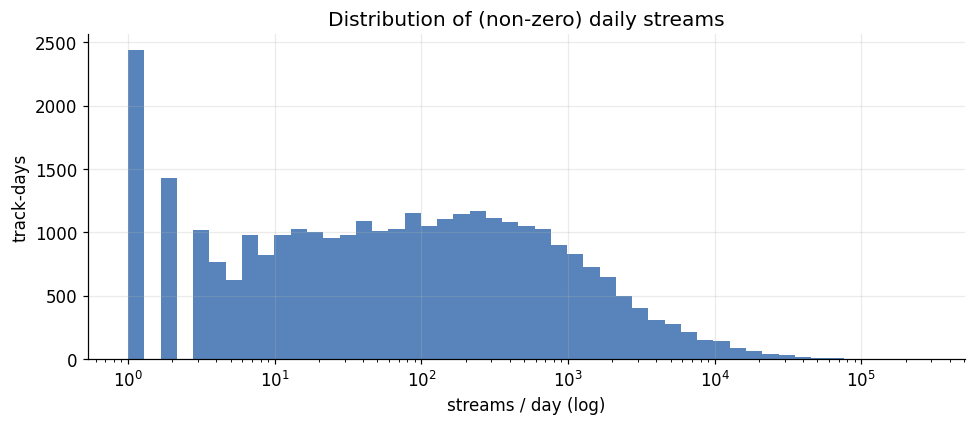

In [10]:
nz = panel.streams[panel.streams > 0]
desc = panel.streams.describe()
extra = pd.Series({"skew": panel.streams.skew(), "kurtosis": panel.streams.kurt(),
                   "% zero days": (panel.streams == 0).mean()*100})
print(pd.concat([desc, extra]).to_frame("daily streams"))

fig, ax = plt.subplots(figsize=(9, 4))
bins = np.logspace(0, np.log10(nz.max()), 50)
ax.hist(nz, bins=bins, color="#3b6fb0", alpha=0.85)
ax.set_xscale("log"); ax.set_title("Distribution of (non-zero) daily streams")
ax.set_xlabel("streams / day (log)"); ax.set_ylabel("track-days")
plt.tight_layout(); plt.show()

## 7 · Concentration — do hits dominate? (and why it will haunt us)

Lorenz curve and Gini over **total streams per track** (using `mml.gini`). The further the curve bows from
the 45° line, the more lopsided the catalog. **What to look for:** a Gini well above 0 and a top-few-percent
share that dwarfs the rest — the textbook music economics where a handful of hits carry the catalog.

This isn't just a fun stylised fact; it's the **central measurement headache** of the whole venture. A
heavy tail means most releases are individually data-poor (little signal to estimate an ad effect from),
while a few dominate the totals. That is exactly why, in Chapter 4, a separate model per release collapses
and we have to **partially pool** across the roster — and why Chapter 6's identification study stress-tests
whether anything is recoverable at all when the data is this thin and lopsided.

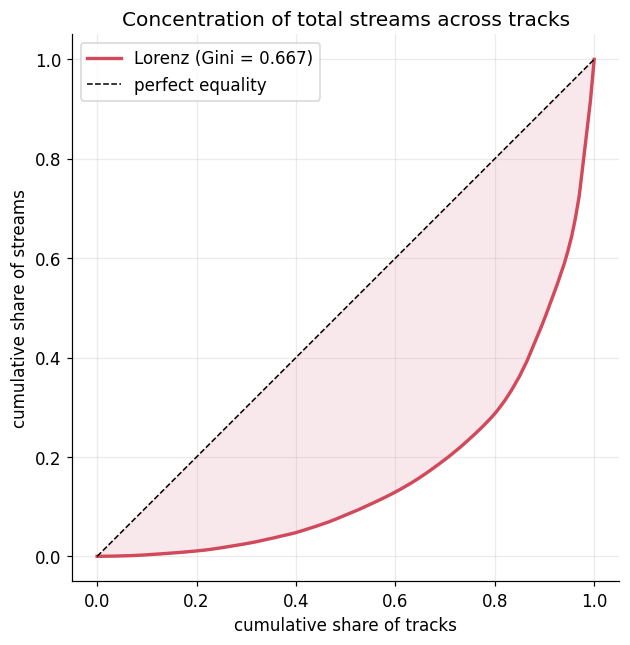

Gini coefficient: 0.667
                   share of all streams
Top 1% of tracks               0.147797
Top 5% of tracks               0.384659
Top 10% of tracks              0.535402
Top 20% of tracks              0.716401


In [11]:
tot = totals.sort_values().values
g = gini(tot)
cum = np.insert(np.cumsum(tot)/tot.sum(), 0, 0)
frac = np.linspace(0, 1, len(cum))

shares = pd.Series({
    "Top 1% of tracks":  tot[int(0.99*len(tot)):].sum()/tot.sum(),
    "Top 5% of tracks":  tot[int(0.95*len(tot)):].sum()/tot.sum(),
    "Top 10% of tracks": tot[int(0.90*len(tot)):].sum()/tot.sum(),
    "Top 20% of tracks": tot[int(0.80*len(tot)):].sum()/tot.sum(),
})

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.plot(frac, cum, color="#d1495b", lw=2.2, label=f"Lorenz (Gini = {g:.3f})")
ax.plot([0,1],[0,1], "k--", lw=1, label="perfect equality")
ax.fill_between(frac, cum, frac, color="#d1495b", alpha=0.12)
ax.set_title("Concentration of total streams across tracks")
ax.set_xlabel("cumulative share of tracks"); ax.set_ylabel("cumulative share of streams")
ax.legend(loc="upper left"); ax.set_aspect("equal"); plt.tight_layout(); plt.show()

print(f"Gini coefficient: {g:.3f}")
print(shares.to_frame("share of all streams"))

## 8 · Per-track summary table

Top and bottom of the catalog by lifetime streams.

In [12]:
per_track = (panel.groupby(["artist_id","track_id"])
             .agg(total_streams=("streams","sum"),
                  peak_day=("streams","max"),
                  days_active=("streams","size"))
             .reset_index()
             .merge(tracks[["track_id","release_date","half_life","quality"]], on="track_id")
             .sort_values("total_streams", ascending=False))
per_track["release_date"] = pd.to_datetime(per_track.release_date).dt.date

print("Top 10 tracks")
print(per_track.head(10))
print("\nBottom 5 tracks")
print(per_track.tail(5))

Top 10 tracks
    artist_id track_id  total_streams  peak_day  days_active release_date  \
91        A21     T091        1980819     65021          232   2025-05-14   
4         A01     T004        1536785     83584          461   2024-09-27   
105       A24     T105        1523132    270907           21   2025-12-11   
10        A02     T010        1496997     46635          697   2024-02-04   
29        A06     T029        1045814     45463          435   2024-10-23   
30        A07     T030         876997     66310           57   2025-11-05   
81        A18     T081         694441     64715          327   2025-02-08   
107       A24     T107         626536     35265           44   2025-11-18   
132       A29     T132         525932     27481          414   2024-11-13   
84        A19     T084         521179     22098          333   2025-02-02   

     half_life   quality  
91   39.776386  4.207983  
4    65.987327  5.292123  
105  31.271009  1.360874  
10   51.878944  3.841842  
29 

## 9 · Takeaways

- **Catalog growth + weekly ripple** — total daily streams trend up as releases
  accumulate, with a clean Friday/weekend seasonal cycle on top.
- **Release-and-decay** is the dominant track-level shape; averaging in event time
  recovers the injected exponential half-life almost exactly.
- **Over-dispersed, heavy-tailed counts** — most track-days are tiny, a few are huge.
- **Hits dominate** — a high Gini and a steep Lorenz curve: the top few percent of
  tracks account for the bulk of all streams, exactly the concentration we built from
  log-normal popularity × quality plus rare viral shocks.

### Knobs to play with
Re-run with overrides passed to `simulate_catalog(seed=..., **overrides)`:
`pop_sigma` / `qual_sigma` (more spread ⇒ higher Gini) · `halflife_med` (longer tails)
· `dow_raw` (seasonality shape) · `viral_*` (frequency/size of spikes) · `nb_r`
(noisiness) · `seed` (a whole new world).

The tidy panel lives in `panel` (one row per track-day) and the release metadata in
`tracks` — export with `panel.to_csv(...)` / `panel.to_parquet(...)` to use elsewhere.